In [28]:
import pandas as pd
import numpy as np
import librosa
import os
import matplotlib.pyplot as plt
from pydub import AudioSegment
import io
import pywt

from config import SAMPLING_RATE, LOW_CUT, HIGH_CUT

In [2]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax);

Estoy usando el dataset filtrado!!!

In [4]:
df = pd.read_csv('./dataset/ciclos_train/train_filenames.csv')
ciclos_filenames = df['cycle_wav_file'].values

ciclos = []
for filename in ciclos_filenames:
    y, sr = librosa.load(os.path.join('./dataset/ciclos/', filename), sr=SAMPLING_RATE)
    ciclos.append((y, sr))

In [5]:
df.head()

,cycle_wav_file,label
0,170_1b3_Pl_mc_AKGC417L_cycle4.wav,1
1,213_1p2_Lr_mc_AKGC417L_cycle4.wav,0
2,198_6p1_Pr_mc_AKGC417L_cycle4.wav,0
3,102_1b1_Ar_sc_Meditron_cycle2.wav,0
4,221_2b2_Al_mc_LittC2SE_cycle3.wav,1


In [6]:
ciclos_propios = []
for filename in os.listdir('./audios_propios/ciclos_energy_based'):
    y, sr = librosa.load(os.path.join('./audios_propios/ciclos_energy_based', filename), sr=SAMPLING_RATE)
    ciclos_propios.append((y, sr))

In [7]:
def bandpass_filter(y, sr=SAMPLING_RATE, lowcut=LOW_CUT, highcut=HIGH_CUT):
    from scipy.signal import butter, lfilter
    nyquist = 0.5 * sr
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(4, [low, high], btype='band')
    y_filtered = lfilter(b, a, y)
    return y_filtered

def resample(y, orig_sr, target_sr=SAMPLING_RATE):
    return librosa.resample(y, orig_sr=orig_sr, target_sr=target_sr)

In [8]:
ciclos_proc = []

for ciclo in ciclos:
    y, sr = ciclo
    y = resample(y, orig_sr=sr, target_sr=SAMPLING_RATE)
    ciclos_proc.append(y)


ciclos_propios_proc = []
for ciclo in ciclos_propios:
    y, sr = ciclo
    y = resample(y, orig_sr=sr, target_sr=SAMPLING_RATE)
    ciclos_propios_proc.append(y)

## Bandpass

A ambos conjuntos de datos

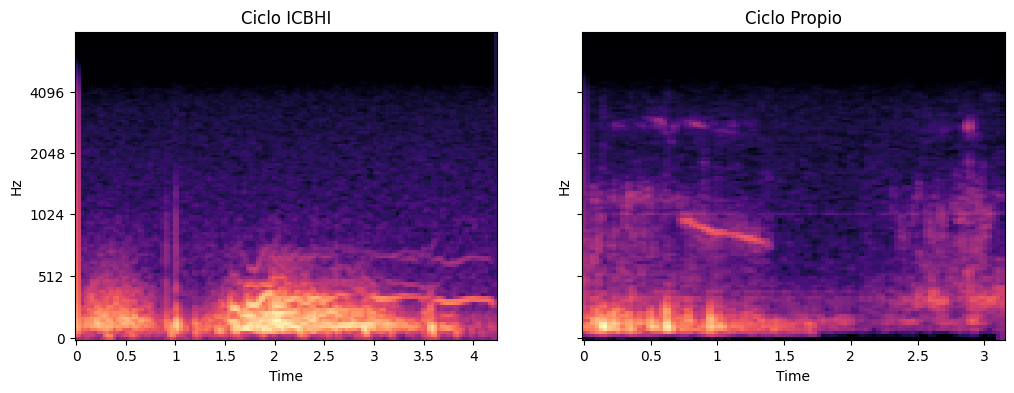

In [13]:
ciclo_icbhi = bandpass_filter(ciclos_proc[4])
ciclo_propio = bandpass_filter(ciclos_propios_proc[23])

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_mel_spectrogram(ciclo_icbhi, ax=axs[0])
plot_mel_spectrogram(ciclo_propio, ax=axs[1])
axs[0].set_title('Ciclo ICBHI')
axs[1].set_title('Ciclo Propio');

Se parecen bastante con el bandpass

In [14]:
ciclo_icbhi.mean(), ciclo_propio.mean()

(np.float64(-1.7912379145811747e-07), np.float64(1.1182881820201555e-07))

## Agregado de reverberación

In [15]:
def add_reverb(y, sr, reverb_amount=0.2):
    # convolución sencilla con un RIR sintético (decay exponencial)
    length = int(sr * 0.2)  # 200 ms rir
    t = np.linspace(0, 1, length)
    rir = np.exp(-5 * t)  # decay
    rir /= np.sum(np.abs(rir))
    conv = np.convolve(y, rir)[:len(y)]
    return (1-reverb_amount)*y + reverb_amount*conv

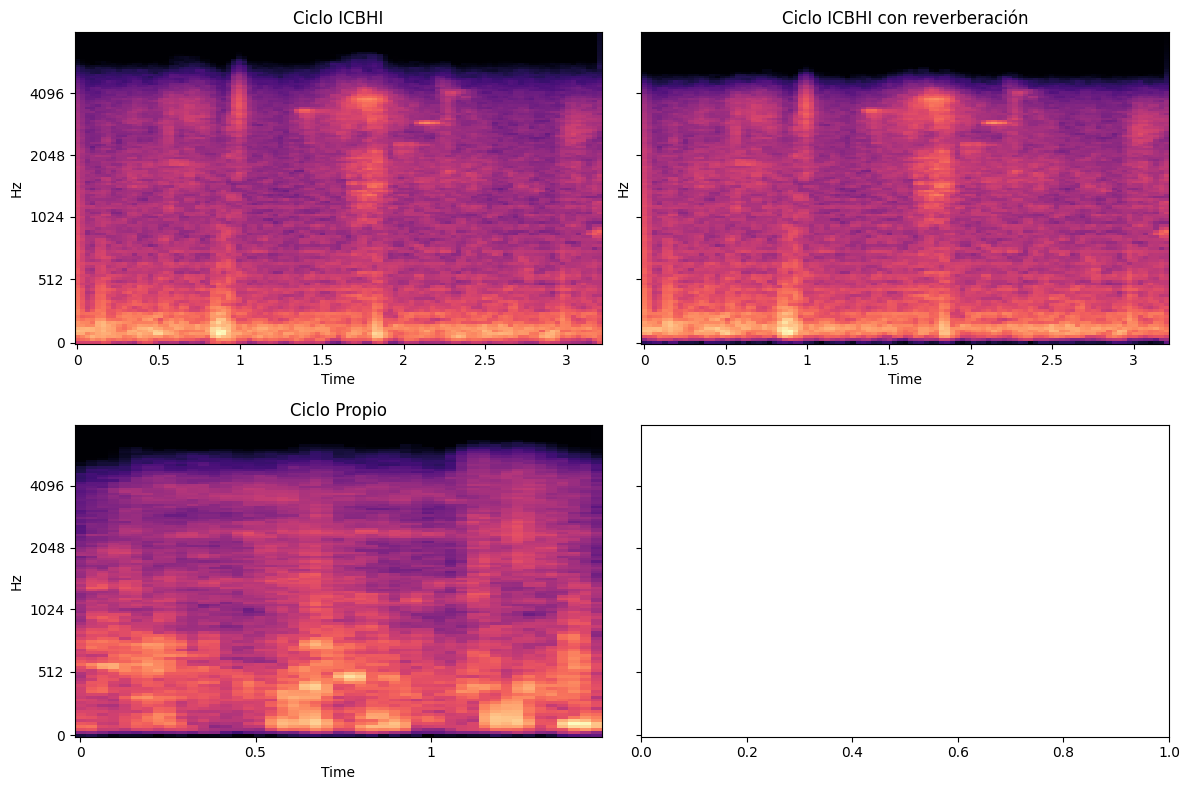

In [20]:
ciclo_icbhi = bandpass_filter(ciclos_proc[1])
ciclo_icbhi_rev = bandpass_filter(add_reverb(ciclo_icbhi, SAMPLING_RATE))
ciclo_propio = bandpass_filter(ciclos_propios_proc[12])

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
plot_mel_spectrogram(ciclo_icbhi, ax=axs[0, 0])
plot_mel_spectrogram(ciclo_icbhi_rev, ax=axs[0, 1])
plot_mel_spectrogram(ciclo_propio, ax=axs[1, 0])
axs[0, 0].set_title('Ciclo ICBHI')
axs[0, 1].set_title('Ciclo ICBHI con reverberación')
axs[1, 0].set_title('Ciclo Propio')
plt.tight_layout();

No noto ningún cambio importante

In [21]:
ciclo_icbhi.mean(), ciclo_icbhi_rev.mean(), ciclo_propio.mean()

(np.float64(-1.3157843082129835e-05),
 np.float64(-3.6521777241847647e-07),
 np.float64(-1.652728876716759e-08))

## Agregado de ruido

In [ ]:
def add_noise(y, snr_db=random.uniform(5, 10)):
    rms = np.sqrt(np.mean(y**2))
    snr = 10**(snr_db/20.0)
    noise_rms = rms / snr
    noise = np.random.normal(0, noise_rms, y.shape)
    return y + noise

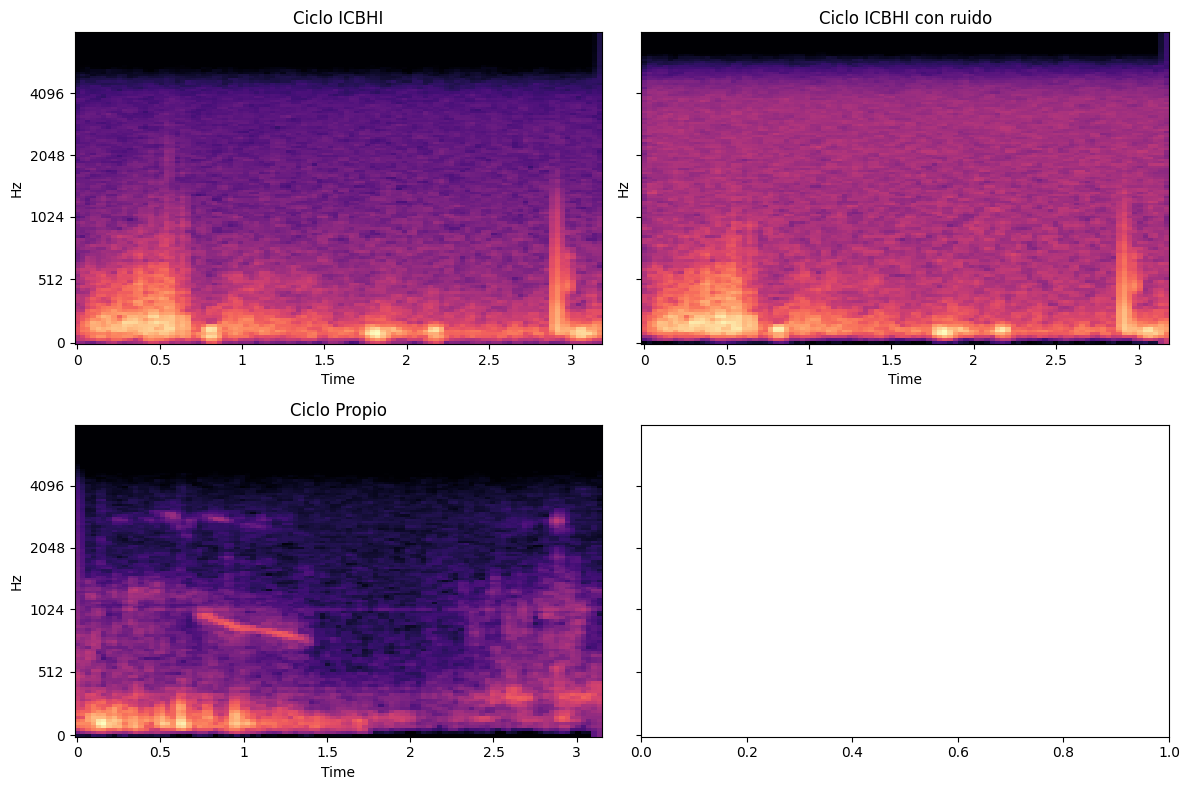

In [26]:
ciclo_icbhi = bandpass_filter(ciclos_proc[8])
ciclo_icbhi_rev = bandpass_filter(add_noise(ciclo_icbhi, snr_db=15))
ciclo_propio = bandpass_filter(ciclos_propios_proc[23])

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
plot_mel_spectrogram(ciclo_icbhi, ax=axs[0, 0])
plot_mel_spectrogram(ciclo_icbhi_rev, ax=axs[0, 1])
plot_mel_spectrogram(ciclo_propio, ax=axs[1, 0])
axs[0, 0].set_title('Ciclo ICBHI')
axs[0, 1].set_title('Ciclo ICBHI con ruido')
axs[1, 0].set_title('Ciclo Propio')
plt.tight_layout();

Que pasa si le quito el ruido al audio con ruido agregado?

In [29]:
def wavelet_denoise(signal, wavelet='db4', level=4, threshold_method='soft'):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745  # estimación del ruido
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresh = [coeffs[0]] + [
        pywt.threshold(c, value=uthresh, mode=threshold_method)
        for c in coeffs[1:]
    ]
    return pywt.waverec(coeffs_thresh, wavelet)

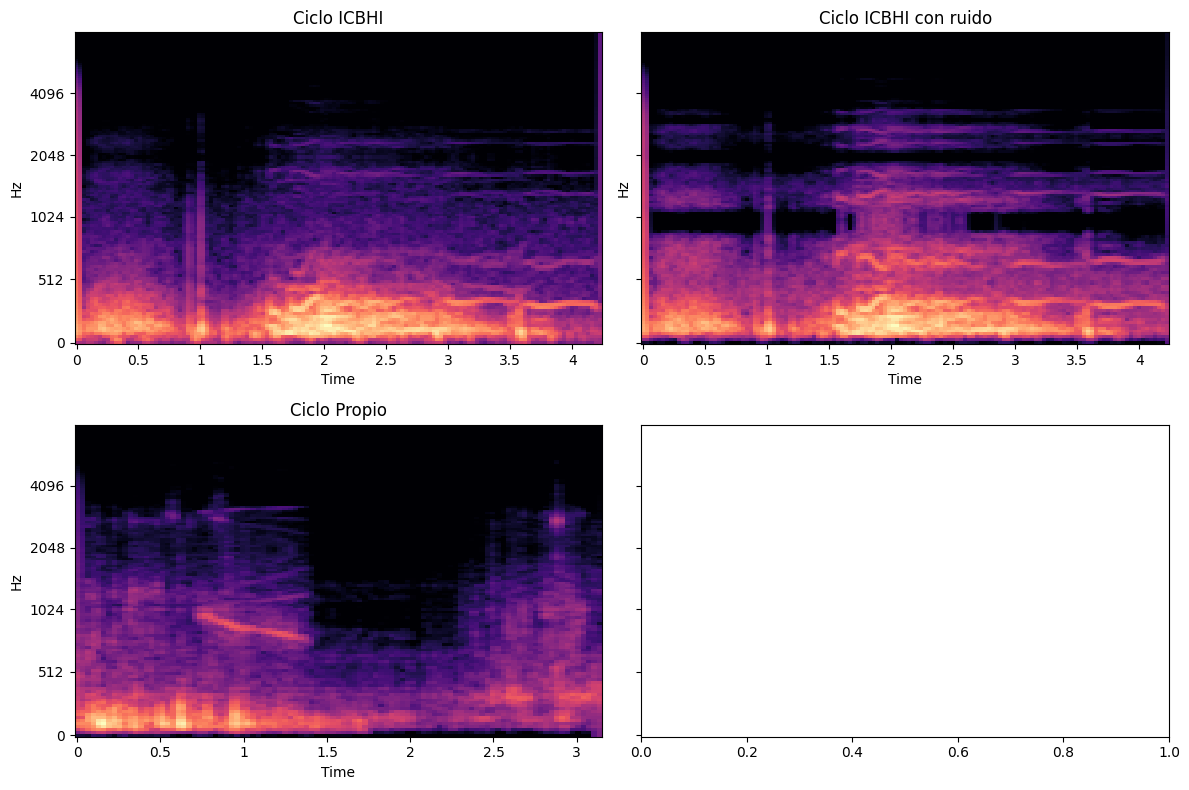

In [38]:
ciclo_icbhi = bandpass_filter(wavelet_denoise(ciclos_proc[4]))
ciclo_icbhi_rev = bandpass_filter(wavelet_denoise(add_noise(ciclo_icbhi, snr_db=15)))
ciclo_propio = bandpass_filter(wavelet_denoise(ciclos_propios_proc[23]))

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
plot_mel_spectrogram(ciclo_icbhi, ax=axs[0, 0])
plot_mel_spectrogram(ciclo_icbhi_rev, ax=axs[0, 1])
plot_mel_spectrogram(ciclo_propio, ax=axs[1, 0])
axs[0, 0].set_title('Ciclo ICBHI')
axs[0, 1].set_title('Ciclo ICBHI con ruido')
axs[1, 0].set_title('Ciclo Propio')
plt.tight_layout();